First 5 Rows of Dataset:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kath

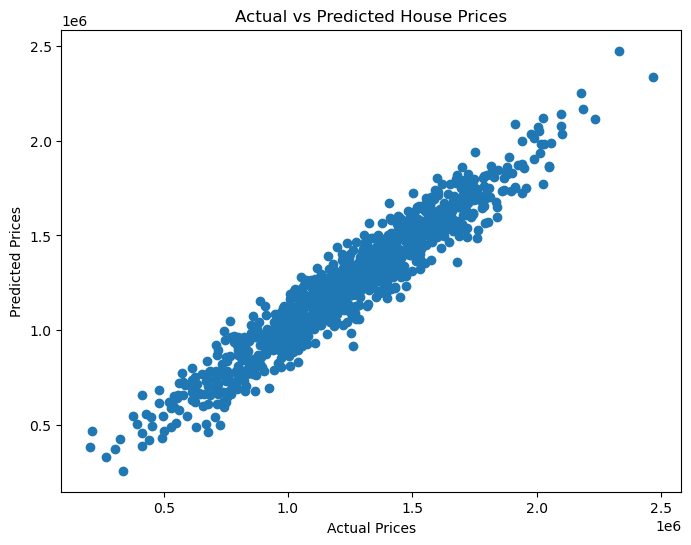

In [3]:
# =========================================================
# Deep Learning Lab 1
# Linear Regression Model for USA House Price Prediction
# =========================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import machine learning modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =========================================================
# Load the dataset
# =========================================================

df = pd.read_csv("USA_Housing.csv")

# =========================================================
# Display first 5 rows of dataset
# =========================================================

print("First 5 Rows of Dataset:")
print(df.head())

# =========================================================
# Display dataset information
# =========================================================

print("\nDataset Information:")
print(df.info())

# =========================================================
# Check missing values
# =========================================================

print("\nMissing Values:")
print(df.isnull().sum())

# =========================================================
# Remove missing values if any
# =========================================================

df = df.dropna()

# =========================================================
# Select input features (X)
# =========================================================

X = df[['Avg. Area Income',
        'Avg. Area House Age',
        'Avg. Area Number of Rooms',
        'Avg. Area Number of Bedrooms',
        'Area Population']]

# =========================================================
# Select target variable (y)
# =========================================================

y = df['Price']

# =========================================================
# Split dataset into training and testing data
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# Create Linear Regression Model
# =========================================================

model = LinearRegression()

# =========================================================
# Train the model
# =========================================================

model.fit(X_train, y_train)

# =========================================================
# Predict house prices using test data
# =========================================================

y_pred = model.predict(X_test)

# =========================================================
# Evaluate the model
# =========================================================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# =========================================================
# Display evaluation results
# =========================================================

print("\nModel Performance:")

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

# =========================================================
# Compare Actual vs Predicted Prices
# =========================================================

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted Prices:")
print(comparison.head())

# =========================================================
# Plot Actual vs Predicted Prices
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()